In [5]:
from typing import ClassVar

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from deep_isochron.misc import inv_softplus
from deep_isochron.model.fourier import TruncatedFourier
from deep_isochron.model.invertible import (
    AbstractBijection,
    CouplingFlow,
    MonotonicRQCoupling,
    OffsetedBijection,
    SequentialINN,
    SinhConjugation,
)
from jaxtyping import Array, Float, Int, PRNGKeyArray

In [17]:
from typing import ClassVar

import equinox as eqx
import jax
import jax.numpy as jnp
from deep_isochron.misc import inv_softplus
from jaxtyping import Array, Float, Int, PRNGKeyArray


class MonotonicRationalQuadraticSpline(AbstractBijection):
    dim: ClassVar[int] = 1  # ty: ignore

    _x_widths: Float[Array, " K"]
    _y_widths: Float[Array, " K"]
    _derivs: Float[Array, " K"]

    num_knots: int = eqx.field(static=True)
    xy_range: tuple[float, float] = eqx.field(static=True)
    min_rel_x_bin_width: float = eqx.field(static=True)
    min_rel_y_bin_width: float = eqx.field(static=True)
    min_derivative: float = eqx.field(static=True)
    linear_tails: bool = eqx.field(static=True)

    def __init__(
        self,
        x_widths: Float[Array, " K-1"],
        y_widths: Float[Array, " K-1"],
        derivatives: Float[Array, " K-2"],
        xy_range: tuple[float, float] = (-1, 1),
        min_rel_x_bin_width: float = 1e-3,
        min_rel_y_bin_width: float = 1e-3,
        min_derivative: float = 1e-3,
        linear_tails: bool = True,
    ):
        if not len(x_widths) == len(y_widths) == (len(derivatives) + 1):
            raise ValueError(
                """Lengths of x_widths, y_widths, and derivatives must equal 
                num_knots-1, num_knots-1, num_knots-2, respectively."""
            )
        self._x_widths = x_widths
        self._y_widths = y_widths
        self._derivs = derivatives
        self.num_knots = len(x_widths) + 1

        self.xy_range = xy_range
        self.min_rel_x_bin_width = min_rel_x_bin_width
        self.min_rel_y_bin_width = min_rel_y_bin_width
        self.min_derivative = min_derivative
        self.linear_tails = linear_tails

    @property
    def x_widths(self) -> Float[Array, " K-1"]:
        rel_widths = (
            jax.nn.softmax(self._x_widths)
            * (1 - len(self._x_widths) * self.min_rel_x_bin_width)
            + self.min_rel_x_bin_width
        )
        return rel_widths * (self.xy_range[1] - self.xy_range[0])

    @property
    def y_widths(self) -> Float[Array, " K-1"]:
        rel_widths = (
            jax.nn.softmax(self._y_widths)
            * (1 - len(self._y_widths) * self.min_rel_y_bin_width)
            + self.min_rel_y_bin_width
        )
        return rel_widths * (self.xy_range[1] - self.xy_range[0])

    @property
    def xs(self) -> Float[Array, " K"]:
        return jnp.pad(jnp.cumsum(self.x_widths), pad_width=(1, 0)) + self.xy_range[0]

    @property
    def ys(self) -> Float[Array, " K"]:
        return jnp.pad(jnp.cumsum(self.y_widths), pad_width=(1, 0)) + self.xy_range[0]

    @property
    def derivs(self) -> Float[Array, " K"]:
        return jnp.pad(
            jax.nn.softplus(self._derivs) + self.min_derivative,
            1,
            mode="constant",
            constant_values=1,
        )

    def compute_bin_and_normalized_x(
        self, x: Float[Array, ""]
    ) -> tuple[Int[Array, ""], Float[Array, ""]]:
        k = jnp.searchsorted(self.xs, x, method="compare_all") - 1
        xi = (x - self.xs[k]) / (self.x_widths[k])
        return k, xi

    def __call__(self, x):
        condlist = [x <= self.xy_range[0], x >= self.xy_range[1]]
        s = self.y_widths / self.x_widths

        def _x_leq_x_min(x):
            return self.ys[0] + self.derivs[0] * (x - self.xs[0])

        def _x_gt_x_max(x):
            return self.ys[-1] + self.derivs[-1] * (x - self.xs[-1])

        def _in_bounds(x):
            k, xi = self.compute_bin_and_normalized_x(x)
            numer = (s[k] * xi**2 + self.derivs[k] * xi * (1 - xi)) * self.y_widths[k]
            denom = s[k] + (self.derivs[k + 1] + self.derivs[k] - 2 * s[k]) * xi * (
                1 - xi
            )
            return self.ys[k] + numer / denom

        return jnp.piecewise(x, condlist, [_x_leq_x_min, _x_gt_x_max, _in_bounds])

    def inverse(self, y):
        condlist = [y <= self.xy_range[0], y >= self.xy_range[1]]
        s = self.y_widths / self.x_widths

        def _y_leq_y_min(y):
            return self.xs[0] + (y - self.ys[0]) / self.derivs[0]

        def _y_gt_y_max(y):
            return self.xs[-1] + (y - self.ys[-1]) / self.derivs[-1]

        def _in_bounds(y):
            k = jnp.searchsorted(self.ys, y, method="compare_all") - 1
            Dy = y - self.ys[k]
            _common = Dy * (self.derivs[k + 1] + self.derivs[k] - 2 * s[k])

            a = self.y_widths[k] * (s[k] - self.derivs[k]) + _common
            b = self.y_widths[k] * self.derivs[k] - _common
            c = -s[k] * Dy

            xi = 2 * c / (-b - jnp.sqrt(b**2 - 4 * a * c))
            return self.xs[k] + xi * self.x_widths[k]

        return jnp.piecewise(y, condlist, [_y_leq_y_min, _y_gt_y_max, _in_bounds])

In [18]:
num_knots = 10
bijection = MonotonicRationalQuadraticSpline(
    jax.random.normal(jax.random.key(0), (num_knots - 1,)),
    jax.random.normal(jax.random.key(1), (num_knots - 1,)),
    jax.random.normal(jax.random.key(2), (num_knots - 2,)),
)

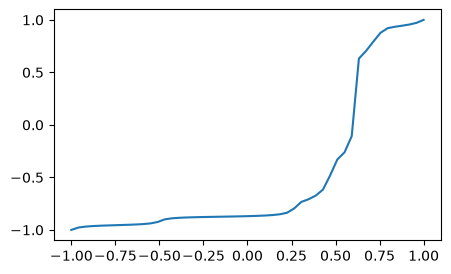

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
x = jnp.linspace(-1, 1, 50)
ax.plot(x, eqx.filter_vmap(bijection)(x))

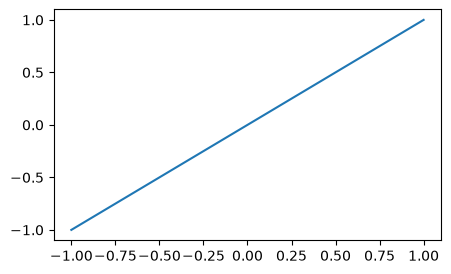

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
x = jnp.linspace(-1, 1, 50)
ax.plot(x, eqx.filter_vmap(lambda x: bijection.inverse(bijection(x)))(x))

In [23]:
coupling = CouplingFlow(dim=5, bijection=bijection, key=jax.random.key(0))

In [24]:
coupling(jnp.zeros((5,)))

Array([0., 0., 0., 0., 0.], dtype=float32)

In [79]:
coupling

CouplingFlow(
  mlp=MLP(
    layers=(
      Linear(
        weight=f32[10,2],
        bias=f32[10],
        in_features=2,
        out_features=10,
        use_bias=True
      ),
      Linear(
        weight=f32[120,10],
        bias=f32[120],
        in_features=10,
        out_features=120,
        use_bias=True
      )
    ),
    activation=<PjitFunction of <function relu at 0x154992388360>>,
    final_activation=<function <lambda>>,
    use_bias=True,
    use_final_bias=True,
    in_size=2,
    out_size=120,
    width_size=10,
    depth=1
  ),
  bijection_factory=BijectionFactory(
    _bijection_static=SequentialINN(
      transforms=(
        SinhConjugation(
          loc=None, _scale=None, beta=None, _mu=None, _nu=None, eps_scale=0.1
        ),
        SinhConjugation(
          loc=None, _scale=None, beta=None, _mu=None, _nu=None, eps_scale=0.1
        ),
        SinhConjugation(
          loc=None, _scale=None, beta=None, _mu=None, _nu=None, eps_scale=0.1
        ),
        Si

In [25]:
coupling.inverse(coupling(jnp.zeros((5,))))

Array([0.000000e+00, 0.000000e+00, 7.450581e-09, 7.450581e-09,
       7.450581e-09], dtype=float32)

In [2]:
inv_softplus(0.9)

Array(0.37816453, dtype=float32, weak_type=True)

In [ ]:
key_x, key_y = jax.random.split(jax.random.key(0))
n_knots = 10
dxs = jax.nn.softmax(jax.random.normal(key_x, shape=(n_knots - 1,)))
dys = jax.nn.softmax(jnp.asarray([1.0, 1.0, 1.0, 0.1, 0.1, 0.1, 1.0, 1.0, 1.0]))
# dys= jax.nn.softmax(jax.random.normal(key_y, shape = (n_knots-1,)))
# xs = jnp.pad(jnp.cumsum(dxs), (1, 0))*2*jnp.pi-jnp.pi
ys = jnp.pad(jnp.cumsum(dys), (1, 0)) * 2 * jnp.pi - jnp.pi
# ds = jnp.pad(jax.nn.softplus(jax.random.normal(key_x, shape = (n_knots-1,))), (1, 0), mode="wrap")
xs = jnp.linspace(-jnp.pi, jnp.pi, 10)
# ys = jnp.linspace(-jnp.pi, jnp.pi, 10)
ds = jnp.asarray([0.1] * 3 + [4.0] * 4 + [0.1] * 3)
spl = MonotonicRationalQuadraticSpline(xs, ys, ds)


In [4]:
xs = jnp.linspace(-jnp.pi, jnp.pi, 10)
xs

Array([-3.1415927 , -2.4434612 , -1.7453294 , -1.0471973 , -0.3490659 ,
        0.34906602,  1.0471977 ,  1.7453295 ,  2.4434612 ,  3.1415927 ],      dtype=float32)

In [ ]:
jnp.logical_and(jnp.asarray(1.0) < 3, jnp.asarray(1.0) > 0.5)

Array(True, dtype=bool)

In [5]:
spl.ds

Array([0.1, 0.1, 0.1, 4. , 4. , 4. , 4. , 0.1, 0.1, 0.1], dtype=float32)

In [ ]:
class CircularMonotonicRQCoupling(AbstractBijection):
    """Circular variant of monotonic rational quadratic spline coupling transform, as
    introduced in [1, 2].

    [1] C. Durkan et al. Neural Spline Flows. NeurIPS (2019).
    [2] https://github.com/bayesiains/nflows/blob/master/nflows/transforms/splines/rational_quadratic.py
    """

    theta_offset: Float[Array, ""]
    _dxs: Float[Array, " knots-1"]
    _dys: Float[Array, " knots-1"]
    _derivs: Float[Array, " knots-1"]

    dim: ClassVar[int] = 2  # ty: ignore
    num_knots: int = eqx.field(static=True)
    min_derivative: float = eqx.field(static=True)
    min_rel_x_bin_width: float = eqx.field(static=True)
    min_rel_y_bin_width: float = eqx.field(static=True)

    def __init__(
        self,
        num_knots: int = 10,
        min_rel_x_bin_width: float = 1e-3,
        min_rel_y_bin_width: float = 1e-3,
        min_derivative: float = 1e-3,
        dtype=None,
        *,
        key: PRNGKeyArray,
    ):
        """**Arguments:**

        - `dim`: Dimension of the inputs/outputs of the coupling transform.
        - `min_derivative`: Minimum value of the derivative at the knot points.


        """
        key_x, key_y, key_d = jax.random.split(key, 3)
        self._dxs = jax.random.normal(key_x, (num_knots - 1,))
        self._dys = jax.random.normal(key_y, (num_knots - 1,))
        self._derivs = jax.random.normal(key_d, (num_knots - 1,))
        self.theta_offset = jnp.zeros(())
        self.num_knots = num_knots
        self.min_rel_x_bin_width = min_rel_x_bin_width
        self.min_rel_y_bin_width = min_rel_y_bin_width
        self.min_derivative = min_derivative

    def _make_knots(
        self,
        unnormalized_bin_widths: Float[Array, " {self.num_knots}-1"],
        min_bin_width: float,
    ) -> Float[Array, " {self.num_knots}"]:
        bin_widths = (
            jax.nn.softmax(unnormalized_bin_widths)
            * (1 - self.num_knots * min_bin_width)
            + min_bin_width
        )
        knots = jnp.pad(jnp.cumsum(bin_widths), pad_width=(1, 0))
        return -jnp.pi + 2 * jnp.pi * knots

    def make_spline(self) -> MonotonicRationalQuadraticSpline:
        xs = self._make_knots(self._dxs, self.min_rel_x_bin_width)
        ys = self._make_knots(self._dys, self.min_rel_y_bin_width)
        ds = jnp.pad(
            jax.nn.softplus(self._derivs) + self.min_derivative,
            pad_width=(1, 0),
            mode="wrap",
        )
        return MonotonicRationalQuadraticSpline(xs, ys, ds)

    def __call__(self, x: Float[Array, " 2"]) -> Float[Array, " 2"]:
        r, theta = cartesian_to_polar(x)
        # theta = jnp.mod(theta-self.theta_offset, 2*jnp.pi)-jnp.pi
        spl = self.make_spline()
        theta_out = jnp.piecewise(
            theta,
            [theta < -jnp.pi, theta > jnp.pi],
            [lambda x: x, lambda x: x, lambda x: spl(x)],
        )
        return jnp.stack([r * jnp.cos(theta_out), r * jnp.sin(theta_out)])

    def inverse(self, y: Float[Array, " dim"]) -> Float[Array, " dim"]:
        r, theta = cartesian_to_polar(y)
        # theta = jnp.mod(theta, 2*jnp.pi)-jnp.pi
        spl = self.make_spline()
        theta_in = jnp.piecewise(
            theta,
            [theta < -jnp.pi, theta > jnp.pi],
            [lambda x: x, lambda x: x, lambda x: spl.inverse(x)],
        )
        # theta_in = theta_in+self.theta_offset
        return jnp.stack([r * jnp.cos(theta_in), r * jnp.sin(theta_in)])


In [ ]:
spl_circ = CircularMonotonicRQCoupling(num_knots=10, key=jax.random.key(0))

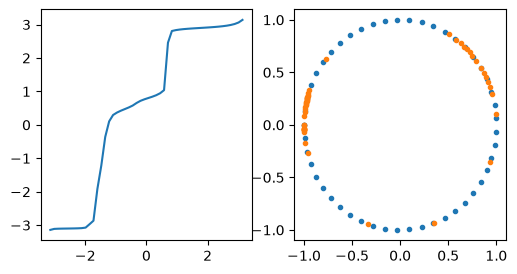

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
theta = jnp.linspace(-jnp.pi + 1e-3, jnp.pi - 1e-3, 50)
theta_out = eqx.filter_vmap(spl_circ.make_spline())(theta)
axes[0].plot(theta, theta_out)
axes[1].plot(jnp.cos(theta), jnp.sin(theta), ".")
axes[1].plot(jnp.cos(theta_out), jnp.sin(theta_out), ".")

In [ ]:
from deep_isochron.misc import cartesian_to_polar
from deep_isochron.systems.normal_forms import BautinNormalForm


def polar_to_cartesian(rtheta):
    r, theta = rtheta
    return jnp.stack((r * jnp.cos(theta), r * jnp.sin(theta)))


normal_form = BautinNormalForm(a=1.0, b=0.5, w=10.0, w0=0.1)

xy0 = jax.random.uniform(jax.random.key(0), (100, 2)) * 6 - 3
polar0 = cartesian_to_polar(xy0.T).T
ts = jnp.arange(0, 5.0, 0.001)
polar_t = eqx.filter_vmap(lambda u0: normal_form.solve(ts, u0))(polar0)
xy_t = eqx.filter_vmap(eqx.filter_vmap(polar_to_cartesian))(polar_t)

In [95]:
xy_out.shape

(100, 2)

In [ ]:
xy_out = eqx.filter_vmap(spl_circ)(xy0)
xy_ae = eqx.filter_vmap(spl_circ.inverse)(xy_out)
jnp.max(jnp.linalg.norm(xy_out - xy_ae, axis=-1))

Array(6.5842304, dtype=float32)

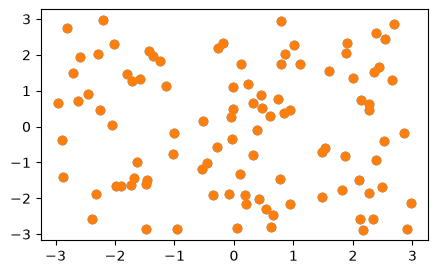

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.scatter(*xy0.T)
ax.scatter(*xy_ae.T)

In [76]:
xy_t.shape

(100, 5000, 2)

In [ ]:
spl_circ(xy_t[0, 0]).shape

(2,)

In [ ]:
xy_out_t = eqx.filter_vmap(eqx.filter_vmap(spl_circ))(xy_t)
xy_out_t.shape

(100, 5000, 2)

In [31]:
xy_out_t.shape

(100, 5000, 2)

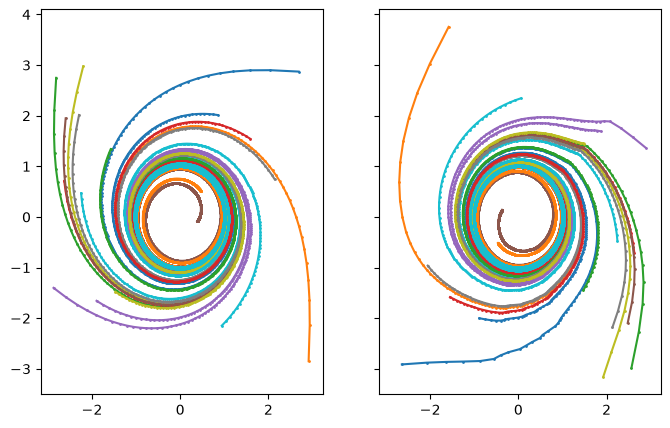

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)
for traj, traj_out in zip(xy_t[::5], xy_out_t[::5]):
    axes[0].plot(*traj.T, ".-", markersize=2)

    traj_out = eqx.filter_vmap(spl_circ)(traj)
    axes[1].plot(*traj_out.T, ".-", markersize=2)

In [ ]:
polar_t.shape

(100, 500, 2)

In [ ]:
fourier = TruncatedFourier(dim=45, order=3)


TypeError: TruncatedFourier.__init__() missing 1 required keyword-only argument: 'key'

In [ ]:
class PolarConditionalBijection(AbstractBijection):
    dim: ClassVar[int] = 2

    center: Float[Array, " dim"]
    log_scale: Float[Array, " dim"]

    fourier: TruncatedFourier

    eps_r: float = eqx.field(static=True)

    def __init__(self, fourier, center, log_scale, eps_r: float = 1e-7):
        self.center = center
        self.log_scale = log_scale
        self.fourier = fourier
        self.eps_r = eps_r

    @property
    def scale(self) -> Float[Array, " dim"]:
        return jnp.exp(self.log_scale)

    def __call__(self, x: Float[Array, " 2"]) -> Float[Array, " 2"]:
        x_scaled = (x - self.center) * self.scale
        r_in = jnp.sqrt(jnp.sum(x_scaled**2) + self.eps_r**2)

        theta = jnp.arctan2(x_scaled[1], x_scaled[0])
        params = jnp.reshape(self.fourier(theta), (9, 5))
        radial_bijection = OffsetedBijection(
            SequentialINN(
                [SinhConjugation.from_unnormalized_params(*p) for p in params]
            )
        )

        r_out = radial_bijection(r_in)

        y_scaled = (r_out / r_in) * x_scaled
        return (y_scaled / self.scale) + self.center

    def inverse(self, y: Float[Array, " 2"]) -> Float[Array, " 2"]:
        y_scaled = (y - self.center) * self.scale
        r_out = jnp.sqrt(jnp.sum(y_scaled**2) + self.eps_r**2)

        theta = jnp.arctan2(y_scaled[1], y_scaled[0])
        params = jnp.reshape(self.fourier(theta), (9, 5))
        radial_bijection = OffsetedBijection(
            SequentialINN(
                [SinhConjugation.from_unnormalized_params(*p) for p in params]
            )
        )

        r_in = radial_bijection.inverse(r_out)

        x_scaled = (r_in / r_out) * y_scaled
        return (x_scaled / self.scale) + self.center

In [ ]:
from deep_isochron.model.invertible import SequentialINN


n_layers = 9

key = jax.random.key(0)
bijection = SequentialINN(
    [
        SinhConjugation.from_unnormalized_params(*jax.random.normal(k, (5,)) * 0.01)
        for k in jax.random.split(key, n_layers)
    ]
)

fourier = TruncatedFourier(dim=45, order=3, init_scale=1.0, key=jax.random.key(0))

radial_bij = PolarConditionalBijection(
    fourier,
    jnp.zeros(
        2,
    ),
    jnp.zeros(
        2,
    ),
)

In [15]:
radial_bij.center

Array([0., 0.], dtype=float32)

In [16]:
def polar_to_cartesian(rtheta):
    r, theta = rtheta
    return jnp.stack((r * jnp.cos(theta), r * jnp.sin(theta)))


theta = jnp.linspace(-jnp.pi, jnp.pi, 100)
xy = polar_to_cartesian(jnp.stack((jnp.ones_like(theta), theta)))

xy_out = eqx.filter_vmap(radial_bij, in_axes=-1, out_axes=-1)(xy)
xy_ae = eqx.filter_vmap(radial_bij.inverse, in_axes=-1, out_axes=-1)(xy_out)

In [17]:
xy_out

Array([[-2.4156570e-03, -4.3204883e-03, -1.2624867e-02, -1.6583420e-02,
        -8.3319722e-03, -5.9333234e-03, -5.1282300e-03, -4.7160173e-03,
        -4.9093692e-03, -5.6169764e-03, -1.6655257e-03, -8.9602824e-04,
        -7.1108545e-04, -1.0074991e-03, -2.2293027e-02, -7.2113262e-03,
        -1.9347046e-02, -3.0709138e-02, -2.6921973e-02, -2.6172480e-02,
        -3.3544634e-02, -7.6756932e-02, -1.5657398e-01, -2.2253422e-01,
        -8.5793156e-03,  2.9214430e-03,  4.9121503e-02,  4.4880826e-02,
         7.2244085e-02,  1.2502237e-01,  2.1159163e-01,  3.6949062e-01,
         5.2875481e+00,  5.7528396e+00,  5.1144272e-01,  6.9457270e-02,
         3.5057649e-02,  7.0312306e-02,  5.6702802e-03,  9.4409492e-03,
         1.6001027e-02,  3.1349923e-02,  2.4833459e-02,  4.6004795e-02,
         5.6493070e-02,  2.2888085e-01,  3.9384878e-01,  2.3776203e-01,
         4.5393363e-01,  5.5682367e-01,  2.7014098e-01,  2.1168646e-01,
         2.1471970e-01,  2.6118416e-01,  3.6046594e-01,  4.81164

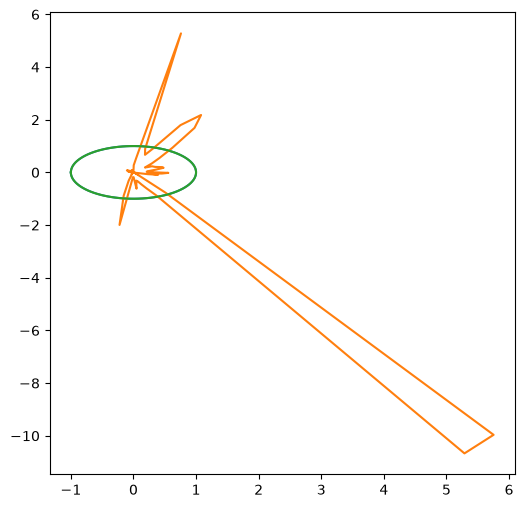

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.plot(*xy)
ax.plot(*xy_out)
ax.plot(*xy_ae)

In [19]:
jnp.max(jnp.linalg.norm(xy_ae - xy, axis=0))

Array(0.00030571, dtype=float32)

In [20]:
jnp.min(jnp.abs(xy_out), axis=-1)

Array([4.3296165e-04, 2.1110007e-10], dtype=float32)

In [13]:
xy_out.shape

(2, 100)

In [11]:
squashed_exp(inv_squashed_exp(0.99) - 10) + 1e-2

Array(0.14535964, dtype=float32, weak_type=True)

In [ ]:
params = jnp.zeros(4)
params = jax.random.normal(jax.random.key(1), (4,))
sinh_conj = CubicConjugation.from_unnormalized_params(*params)


CubicConjugation(
  loc=-0.15443718433380127,
  beta=0.08470727503299713,
  a=0.8743547797203064,
  b=0.27475085854530334
)


9.536743e-07


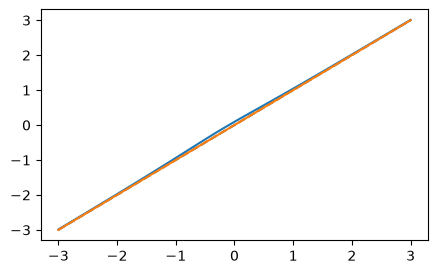

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
x = jnp.linspace(-3, 3, 50)
y = eqx.filter_vmap(sinh_conj)(x)
x_ae = eqx.filter_vmap(sinh_conj.inverse)(y)
ax.plot(x, x, color="black", alpha=0.7, ls="--")
ax.plot(x, y)
ax.plot(x, x_ae)
print(jnp.max(jnp.abs(x - x_ae)))

In [ ]:
class BSpline(AbstractBijection):
    dim: ClassVar[int] = 1  # ty: ignore
    order: int = eqx.field(static=True)
    xs: Float[Array, " K+1"]
    ys: Float[Array, " K+1"]
    ds: Float[Array, " K+1"]
    _x_widths: Float[Array, " K"]
    _y_widths: Float[Array, " K"]
    _s: Float[Array, " K"]

    linear_tails: bool = eqx.field(static=True)

    def __init__(self, xs, ys, ds, linear_tails: bool = True):
        self.xs = xs
        self.ys = ys
        self.ds = ds
        self._x_widths = jnp.diff(xs)
        self._y_widths = jnp.diff(ys)
        self._s = self._y_widths / self._x_widths
        self.linear_tails = linear_tails

    def compute_bin_and_normalized_x(
        self, x: Float[Array, ""]
    ) -> tuple[Int[Array, ""], Float[Array, ""]]:
        k = jnp.searchsorted(self.xs, x, method="compare_all") - 1
        xi = (x - self.xs[k]) / (self.xs[k + 1] - self.xs[k])
        return k, xi

    def bspline_basis(self, x: Float[Array, ""], j, k: int):
        if k == 0:
            return jnp.piecewise((self.xs[j] <= x) & (x < self.xs[j + 1]), 1.0, 0.0)
        else:
            w_jk = (x - self.xs[j]) / (self.xs[j + k] - self.xs[j])
            w_j1k = (x - self.xs[j + 1]) / (self.xs[j + 1 + k] - self.xs[j + 1])
            return w_jk * self.bspline_basis(x, j, k - 1) + w_j1k * self.bspline_basis(
                x, j + 1, k - 1
            )

    def __call__(self, x):
        condlist = [x < self.xs[0], x >= self.xs[-1]]

        def _x_leq_x_min(x):
            return self.ys[0] + self.ds[0] * (x - self.xs[0])

        def _x_gt_x_max(x):
            return self.ys[-1] + self.ds[-1] * (x - self.xs[-1])

        def _in_bounds(x):
            k, xi = self.compute_bin_and_normalized_x(x)
            numer = (self._s[k] * xi**2 + self.ds[k] * xi * (1 - xi)) * self._y_widths[
                k
            ]
            denom = self._s[k] + (self.ds[k + 1] + self.ds[k] - 2 * self._s[k]) * xi * (
                1 - xi
            )
            return self.ys[k] + numer / denom

        return jnp.piecewise(x, condlist, [_x_leq_x_min, _x_gt_x_max, _in_bounds])

    def inverse(self, y):
        condlist = [y < self.ys[0], y >= self.ys[-1]]

        def _y_leq_y_min(y):
            return self.xs[0] + (y - self.ys[0]) / self.ds[0]

        def _y_gt_y_max(y):
            return self.xs[-1] + (y - self.ys[-1]) / self.ds[-1]

        def _in_bounds(y):
            k = jnp.searchsorted(self.ys, y, method="compare_all") - 1
            Dy = y - self.ys[k]
            _common = Dy * (self.ds[k + 1] + self.ds[k] - 2 * self._s[k])

            a = self._y_widths[k] * (self._s[k] - self.ds[k]) + _common
            b = self._y_widths[k] * self.ds[k] - _common
            c = -self._s[k] * Dy

            xi = 2 * c / (-b - jnp.sqrt(b**2 - 4 * a * c))
            return self.xs[k] + xi * self._x_widths[k]

        return jnp.piecewise(y, condlist, [_y_leq_y_min, _y_gt_y_max, _in_bounds])

In [2]:
xs = jnp.linspace(-1, 1, 10)
ys = jnp.linspace(-1, 1, 10)
ds = jax.random.uniform(jax.random.key(0), (10,), minval=0.2, maxval=5.0)

spline = MonotonicRationalQuadraticSpline(xs, ys, ds)

In [3]:
x_test = jnp.linspace(-1.1, 1.1, 100)
y_test = jax.jit(jax.vmap(spline))(x_test)
x_inv_test = jax.vmap(spline.inverse)(y_test)

In [4]:
jnp.max(jnp.abs(x_test - x_inv_test))

Array(1.1920929e-07, dtype=float32)

In [5]:
y_test

Array([-1.4748802 , -1.3693511 , -1.2638218 , -1.1582938 , -1.0527647 ,
       -0.96282095, -0.92933714, -0.9129875 , -0.9024259 , -0.89414114,
       -0.88645816, -0.8780902 , -0.8673308 , -0.85056937, -0.8161056 ,
       -0.7350524 , -0.68783367, -0.6618399 , -0.64486086, -0.6323362 ,
       -0.62205446, -0.6126153 , -0.6027315 , -0.5905051 , -0.5715039 ,
       -0.53793186, -0.51212615, -0.49314246, -0.47746366, -0.46316004,
       -0.44887418, -0.43333247, -0.41494283, -0.391183  , -0.35720122,
       -0.31057948, -0.2813595 , -0.26239938, -0.24799171, -0.23553818,
       -0.22344649, -0.21032917, -0.19442903, -0.1727007 , -0.1382832 ,
       -0.08221852, -0.04035076, -0.01110031,  0.01093236,  0.02860485,
        0.04364379,  0.05725926,  0.07048795,  0.0844871 ,  0.10098706,
        0.12181582,  0.1416274 ,  0.16015059,  0.17817992,  0.19638214,
        0.21538967,  0.2358769 ,  0.2586422 ,  0.28471604,  0.3155281 ,
        0.34929204,  0.3708764 ,  0.38600618,  0.39851293,  0.41

In [6]:
jnp.max(x_inv_test - x_test)

Array(1.1920929e-07, dtype=float32)

In [7]:
ds[0]

Array(4.7488017, dtype=float32)

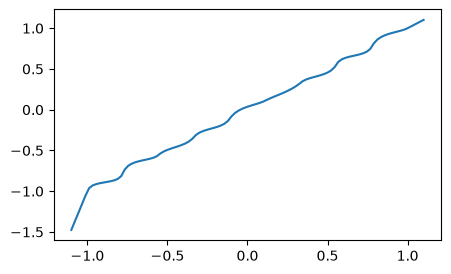

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x_test, y_test)

In [9]:
inn = MonotonicRQCoupling(dim=2, key=jax.random.key(0), xy_range=(-5, 5))

In [12]:
x_test = jax.random.uniform(jax.random.key(10), (100, 2), minval=-3, maxval=3)
y_test = eqx.filter_vmap(inn)(x_test)
x_recon = eqx.filter_vmap(inn.inverse)(y_test)

In [13]:
x_test.shape

(100, 2)

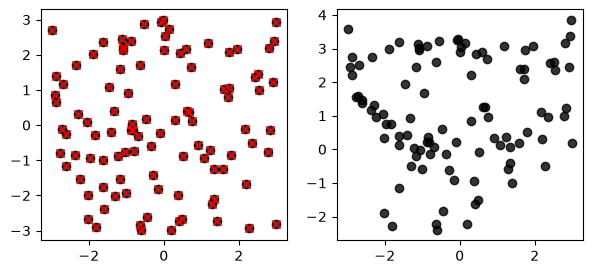

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].scatter(*x_test.T, marker="o", color="black", alpha=0.8)
axes[0].scatter(*x_recon.T, marker="x", color="red", alpha=0.8)
axes[1].scatter(*y_test.T, color="black", alpha=0.8)